In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")

raw = pd.read_csv("house_price_prediction_dataset.csv")
print("Shape:", raw.shape)
raw.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (125, 9)


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8


In [2]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    object 
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 8.9+ KB


In [3]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
House_ID,125.0,NaN,NaN,NaN,1059.0,34.938887,1001.0,1028.0,1058.0,1089.0,1120.0
Area_m2,123.0,NaN,NaN,NaN,134.808943,133.300251,26.0,82.45,107.9,141.0,1200.0
Bedrooms,124.0,NaN,NaN,NaN,3.298387,1.216284,1.0,2.0,3.0,4.0,6.0
Bathrooms,124.0,NaN,NaN,NaN,3.016129,1.202868,1.0,2.0,3.0,4.0,5.0
House_Age_Years,124.0,NaN,NaN,NaN,9.773387,10.435564,0.4,3.175,6.65,12.125,75.0
Distance_to_City_km,124.0,NaN,NaN,NaN,5.652419,8.701097,0.07,1.5575,3.535,7.0725,85.0
Parking_Spaces,124.0,NaN,NaN,NaN,1.185484,0.849361,0.0,1.0,1.0,2.0,3.0
Neighborhood,124,6,Huye,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_Price_Million_RWF,124.0,NaN,NaN,NaN,173.254032,127.372543,77.7,118.525,150.65,186.675,1200.0


In [4]:
missing = raw.isna().sum().to_frame("missing")
missing["percent"] = (missing["missing"] / len(raw) * 100).round(1)
display(missing)
raw[raw.isna().any(axis=1)]

,missing,percent
House_ID,0,0.0
Area_m2,2,1.6
Bedrooms,1,0.8
Bathrooms,1,0.8
House_Age_Years,1,0.8
Distance_to_City_km,1,0.8
Parking_Spaces,1,0.8
Neighborhood,1,0.8
House_Price_Million_RWF,1,0.8


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
7,1008,NaN,4.0,3.0,2.2,2.51,1.0,Huye,177.1
14,1015,42.6,NaN,3.0,10.3,1.55,0.0,Gasabo,112.6
22,1023,114.2,3.0,NaN,4.9,1.58,2.0,Kicukiro,185.2
31,1032,304.7,2.0,2.0,NaN,4.01,0.0,Kigali City,249.1
39,1040,122.6,5.0,5.0,6.9,NaN,2.0,Huye,213.4
51,1052,89.0,2.0,2.0,6.1,4.40,NaN,Musanze,112.4
63,1064,57.0,3.0,3.0,0.5,1.56,1.0,NaN,139.3
79,1080,36.9,1.0,1.0,7.8,11.67,1.0,Musanze,NaN
103,1104,NaN,6.0,5.0,5.8,2.09,1.0,Kicukiro,177.7


In [5]:
print("Fully duplicated rows:", raw.duplicated().sum())
raw[raw.duplicated(keep=False)].sort_values("House_ID")

Fully duplicated rows: 5


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
10,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
120,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
123,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
25,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
121,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
124,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
40,1041,165.1,5.0,5.0,6.2,8.84,0.0,Huye,236.2
122,1041,165.1,5.0,5.0,6.2,8.84,0.0,Huye,236.2


In [6]:
num_cols = ["Area_m2","Bedrooms","Bathrooms","House_Age_Years",
            "Distance_to_City_km","Parking_Spaces","House_Price_Million_RWF"]

def iqr_report(df, cols):
    rows = []
    for c in cols:
        q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        n = ((df[c] < lo) | (df[c] > hi)).sum()
        rows.append([c, round(lo,1), round(hi,1), n])
    return pd.DataFrame(rows, columns=["Column","Lower fence","Upper fence","Flagged"])

iqr_report(raw.drop_duplicates(), num_cols)

,Column,Lower fence,Upper fence,Flagged
0,Area_m2,-10.0,234.5,11
1,Bedrooms,-1.0,7.0,0
2,Bathrooms,-1.0,7.0,0
3,House_Age_Years,-10.9,26.1,9
4,Distance_to_City_km,-6.5,15.0,7
5,Parking_Spaces,-0.5,3.5,0
6,House_Price_Million_RWF,20.0,287.1,4


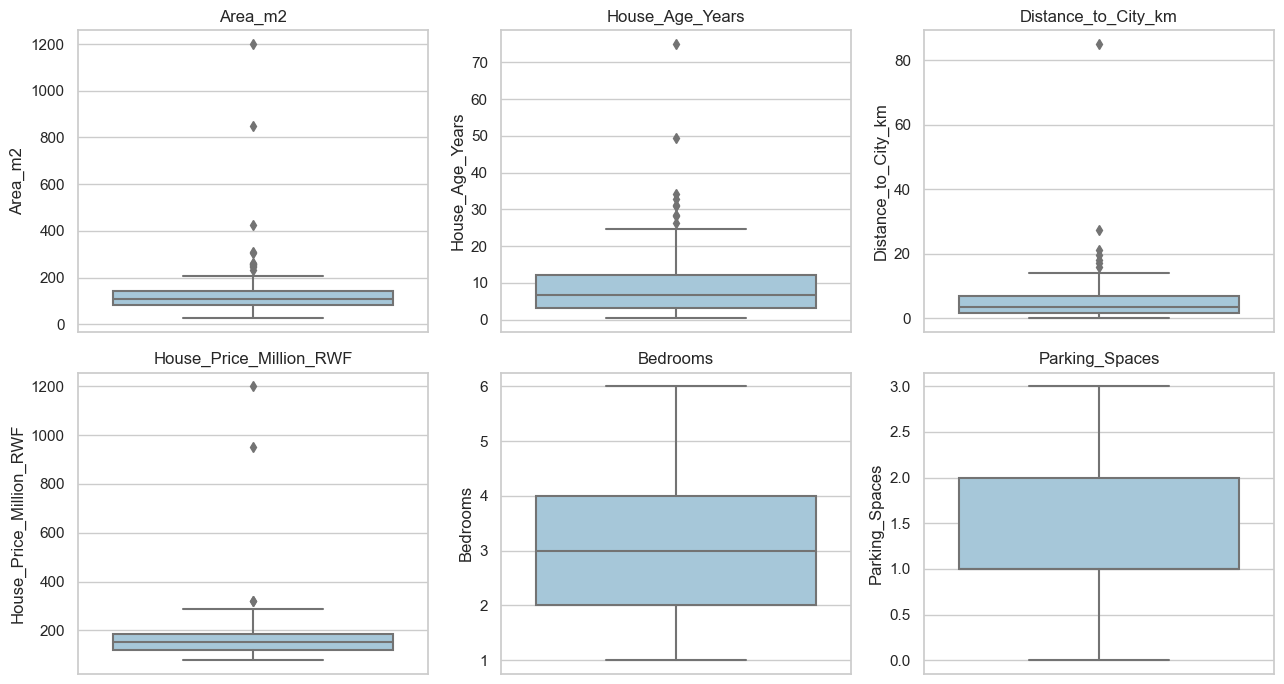

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), ["Area_m2","House_Age_Years","Distance_to_City_km",
                                "House_Price_Million_RWF","Bedrooms","Parking_Spaces"]):
    sns.boxplot(y=raw[c], ax=ax, color="#9ecae1"); ax.set_title(c)
plt.tight_layout(); plt.show()

In [8]:
suspects = raw[(raw.Area_m2 > 400) | (raw.House_Age_Years > 40) |
               (raw.Distance_to_City_km > 40) | (raw.House_Price_Million_RWF > 500)]
suspects

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
5,1006,850.0,3.0,3.0,2.1,15.93,0.0,Kigali City,150.2
18,1019,1200.0,4.0,4.0,10.6,0.16,3.0,Huye,152.9
33,1034,61.5,5.0,5.0,75.0,2.65,1.0,Kigali City,179.6
47,1048,196.7,1.0,1.0,3.9,85.00,1.0,Nyarugenge,199.6
62,1063,59.9,4.0,4.0,49.5,0.24,1.0,Kicukiro,92.7
72,1073,107.9,4.0,4.0,5.0,7.85,2.0,Musanze,950.0
91,1092,187.4,4.0,4.0,3.6,3.71,1.0,Gasabo,1200.0
113,1114,426.4,4.0,4.0,22.6,3.62,2.0,Musanze,319.0


In [9]:
df = raw.drop_duplicates().copy()
df = df.dropna(subset=["House_Price_Million_RWF"])

bad_ids = [1006, 1019, 1048, 1073, 1092]
df = df[~df.House_ID.isin(bad_ids)].reset_index(drop=True)

print("Rows: raw", len(raw), "-> cleaned", len(df))
print(df.isna().sum()[df.isna().sum() > 0])
df.to_csv("house_price_cleaned.csv", index=False)
df.describe().T.round(2)

Rows: raw 125 -> cleaned 114
Area_m2                2
Bedrooms               1
Bathrooms              1
House_Age_Years        1
Distance_to_City_km    1
Parking_Spaces         1
Neighborhood           1
dtype: int64


,count,mean,std,min,25%,50%,75%,max
House_ID,114.0,1060.89,34.89,1001.00,1031.25,1060.50,1090.75,1120.0
Area_m2,112.0,119.94,65.32,26.00,81.30,105.65,134.45,426.4
Bedrooms,113.0,3.32,1.16,1.00,2.00,3.00,4.00,6.0
Bathrooms,113.0,3.03,1.17,1.00,2.00,3.00,4.00,5.0
House_Age_Years,113.0,10.14,10.84,0.40,2.90,6.90,13.10,75.0
Distance_to_City_km,113.0,4.76,4.77,0.07,1.56,3.27,6.48,27.4
Parking_Spaces,113.0,1.19,0.83,0.00,1.00,1.00,2.00,3.0
House_Price_Million_RWF,114.0,158.90,51.17,77.70,117.98,150.55,185.55,322.0


C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


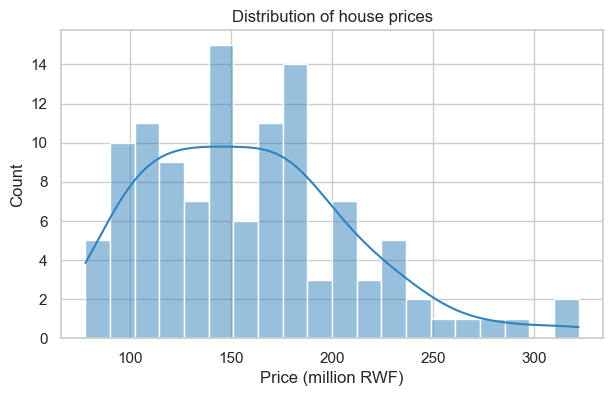

In [10]:
# Cell 10: price distribution
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(df["House_Price_Million_RWF"], bins=20, kde=True, color="#3182bd", ax=ax)
ax.set_xlabel("Price (million RWF)"); ax.set_title("Distribution of house prices")
plt.show()

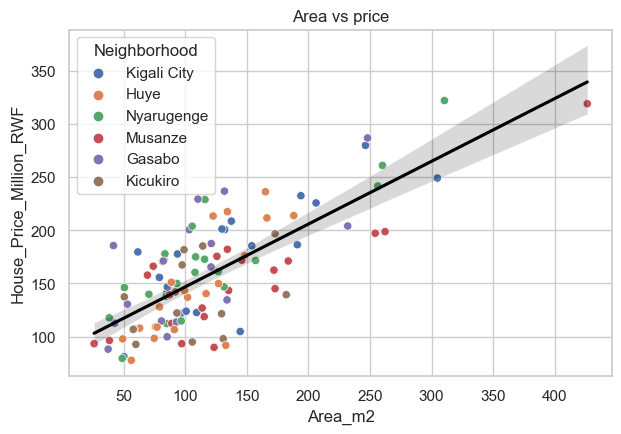

In [11]:
# Cell 11: area vs price
fig, ax = plt.subplots(figsize=(7,4.5))
sns.scatterplot(data=df, x="Area_m2", y="House_Price_Million_RWF", hue="Neighborhood", ax=ax)
sns.regplot(data=df, x="Area_m2", y="House_Price_Million_RWF", scatter=False, color="black", ax=ax)
ax.set_title("Area vs price"); plt.show()

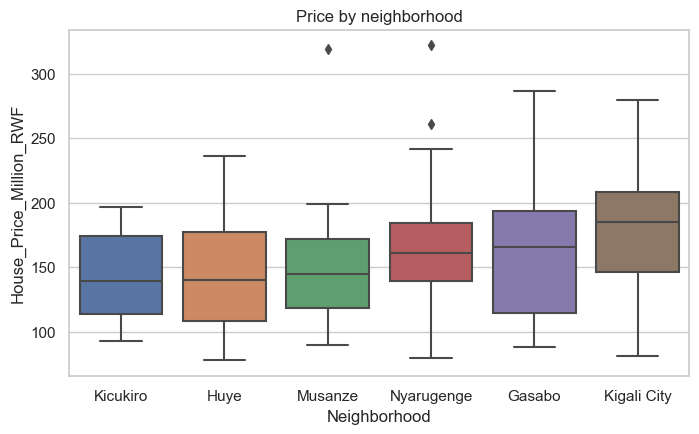

In [12]:
# Cell 12: price by neighborhood
fig, ax = plt.subplots(figsize=(8,4.5))
order = df.groupby("Neighborhood")["House_Price_Million_RWF"].median().sort_values().index
sns.boxplot(data=df, x="Neighborhood", y="House_Price_Million_RWF", order=order, ax=ax)
ax.set_title("Price by neighborhood"); plt.show()

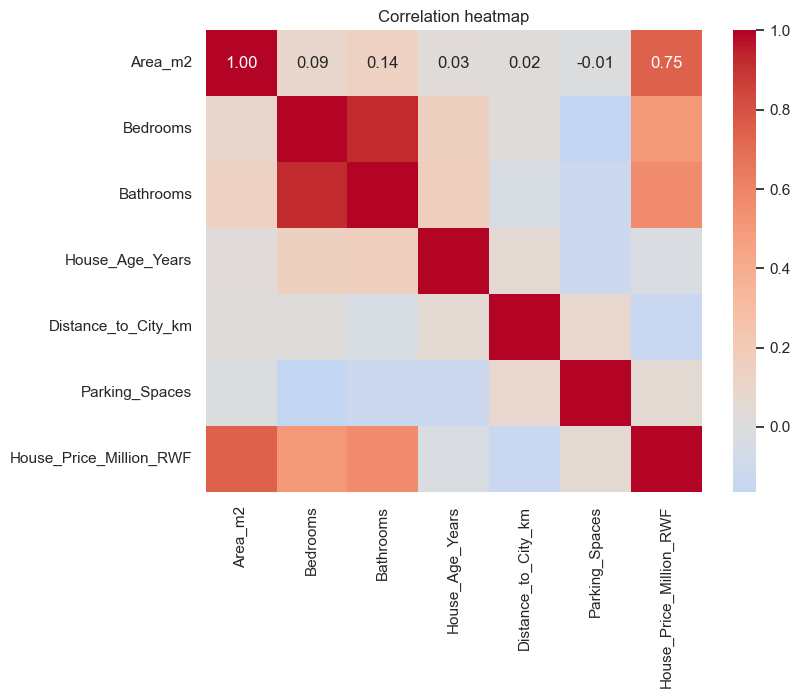

In [13]:
# Cell 13: correlation heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df.drop(columns="House_ID").corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap"); plt.show()

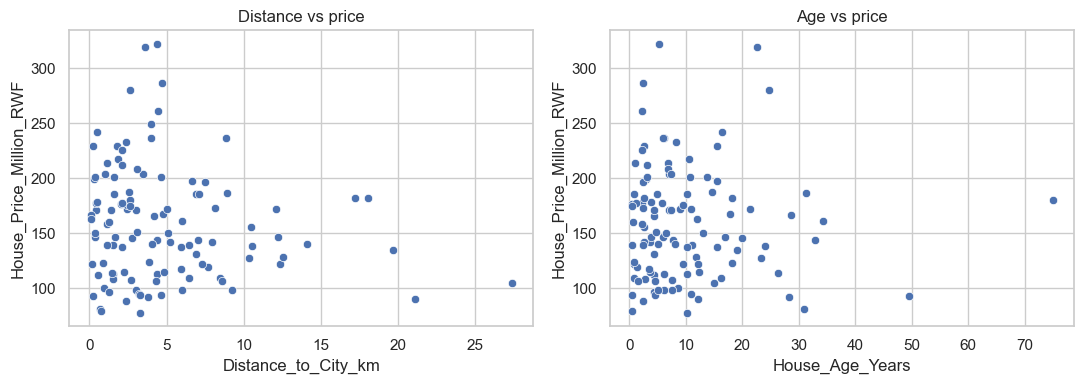

In [14]:
# Cell 14: distance and age vs price
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.scatterplot(data=df, x="Distance_to_City_km", y="House_Price_Million_RWF", ax=axes[0])
sns.scatterplot(data=df, x="House_Age_Years", y="House_Price_Million_RWF", ax=axes[1])
axes[0].set_title("Distance vs price"); axes[1].set_title("Age vs price")
plt.tight_layout(); plt.show()

In [15]:
summary = pd.DataFrame([
 ["Missing target", "House_Price_Million_RWF (ID 1080)", "Row dropped", "Target cannot be imputed honestly"],
 ["Missing numeric features", "Area, Bedrooms, Bathrooms, Age, Distance, Parking", "Median imputation in the Pipeline", "Robust to extremes; learned on training data only"],
 ["Missing category", "Neighborhood (ID 1064)", "Most-frequent imputation in the Pipeline", "Keeps the row; only 1 case"],
 ["Duplicate records", "5 rows (IDs 1011, 1026, 1041 repeated)", "Dropped, first copy kept", "Avoids double counting"],
 ["Impossible area", "850 and 1200 m² (IDs 1006, 1019)", "Rows removed", "Unrealistic; likely decimal slips"],
 ["Extreme price", "950 and 1200 million RWF (IDs 1073, 1092)", "Rows removed", "About 6 times typical; likely entry errors"],
 ["Impossible distance", "85 km in Nyarugenge (ID 1048)", "Row removed", "Contradicts the neighborhood"],
 ["Plausible outliers", "Area 426 m², age 49.5 and 75, small houses", "Kept", "Realistic values, consistent prices"],
 ["Text category", "Neighborhood", "One-hot encoding (Part B)", "Models need numbers"],
 ["Identifier", "House_ID", "Excluded from predictors", "Just a label"],
], columns=["Problem found","Where","Action taken","Reason"])
summary

,Problem found,Where,Action taken,Reason
0,Missing target,House_Price_Million_RWF (ID 1080),Row dropped,Target cannot be imputed honestly
1,Missing numeric features,"Area, Bedrooms, Bathrooms, Age, Distance, Parking",Median imputation in the Pipeline,Robust to extremes; learned on training data only
2,Missing category,Neighborhood (ID 1064),Most-frequent imputation in the Pipeline,Keeps the row; only 1 case
3,Duplicate records,"5 rows (IDs 1011, 1026, 1041 repeated)","Dropped, first copy kept",Avoids double counting
4,Impossible area,"850 and 1200 m² (IDs 1006, 1019)",Rows removed,Unrealistic; likely decimal slips
5,Extreme price,"950 and 1200 million RWF (IDs 1073, 1092)",Rows removed,About 6 times typical; likely entry errors
6,Impossible distance,85 km in Nyarugenge (ID 1048),Row removed,Contradicts the neighborhood
7,Plausible outliers,"Area 426 m², age 49.5 and 75, small houses",Kept,"Realistic values, consistent prices"
8,Text category,Neighborhood,One-hot encoding (Part B),Models need numbers
9,Identifier,House_ID,Excluded from predictors,Just a label


In [16]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("house_price_cleaned.csv")
print(df.shape)

(114, 9)


In [17]:
target = "House_Price_Million_RWF"
X = df.drop(columns=["House_ID", target])
y = df[target]

num_cols = ["Area_m2", "Bedrooms", "Bathrooms", "House_Age_Years",
            "Distance_to_City_km", "Parking_Spaces"]
cat_cols = ["Neighborhood"]

print(X.columns.tolist())
print(X.shape, y.shape)

['Area_m2', 'Bedrooms', 'Bathrooms', 'House_Age_Years', 'Distance_to_City_km', 'Parking_Spaces', 'Neighborhood']
(114, 7) (114,)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (91, 7)  Test: (23, 7)


In [19]:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first"))
    ]), cat_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression())
])
model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Area_m2', 'Bedrooms',
                                                   'Bathrooms',
                                                   'House_Age_Years',
                                                   'Distance_to_City_km',
                                                   'Parking_Spaces']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Neighborhood'])])),
                ('reg', LinearRegression())])

In [20]:
model.fit(X_train, y_train)
print("Model trained")

Model trained


In [21]:
feature_names = model.named_steps["prep"].get_feature_names_out()
feature_names = [n.replace("num__", "").replace("cat__", "") for n in feature_names]

print("Intercept:", round(model.named_steps["reg"].intercept_, 3))

coef_table = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": model.named_steps["reg"].coef_.round(3)
})
coef_table

Intercept: 30.055


,Variable,Coefficient
0,Area_m2,0.549
1,Bedrooms,7.516
2,Bathrooms,15.970
3,House_Age_Years,-0.578
4,Distance_to_City_km,-1.129
5,Parking_Spaces,6.705
6,Neighborhood_Huye,-15.192
7,Neighborhood_Kicukiro,-16.535
8,Neighborhood_Kigali City,14.588
9,Neighborhood_Musanze,-21.706


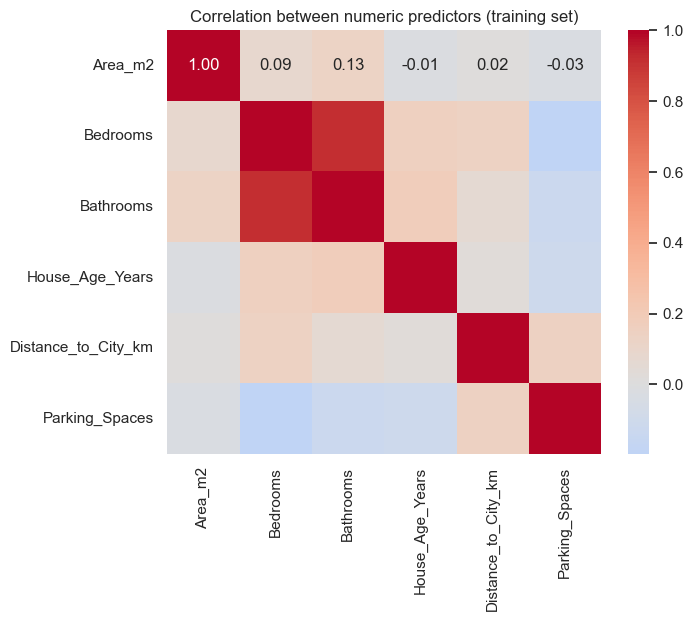

In [22]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(X_train[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric predictors (training set)")
plt.show()

In [23]:
X_enc = pd.DataFrame(model.named_steps["prep"].transform(X_train),
                     columns=feature_names)
X_enc.insert(0, "const", 1.0)

vif = pd.DataFrame({
    "Variable": feature_names,
    "VIF": [variance_inflation_factor(X_enc.values, i)
            for i in range(1, X_enc.shape[1])]
}).round(2)
vif

,Variable,VIF
0,Area_m2,1.20
1,Bedrooms,7.19
2,Bathrooms,7.25
3,House_Age_Years,1.21
4,Distance_to_City_km,1.15
5,Parking_Spaces,1.25
6,Neighborhood_Huye,1.93
7,Neighborhood_Kicukiro,1.67
8,Neighborhood_Kigali City,1.74
9,Neighborhood_Musanze,1.90


In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

In [25]:
def evaluate(X_part, y_part):
    pred = model.predict(X_part)
    n = len(y_part)
    p = len(feature_names)          # 11 predictor columns after encoding
    r2 = r2_score(y_part, pred)
    adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mae = mean_absolute_error(y_part, pred)
    rmse = np.sqrt(mean_squared_error(y_part, pred))
    return [r2, adj, mae, rmse]

metrics = pd.DataFrame(
    [evaluate(X_train, y_train), evaluate(X_test, y_test)],
    index=["Training set", "Test set"],
    columns=["R²", "Adjusted R²", "MAE (million RWF)", "RMSE (million RWF)"]
).round(3)
metrics

,R²,Adjusted R²,MAE (million RWF),RMSE (million RWF)
Training set,0.862,0.843,15.501,18.932
Test set,0.846,0.691,17.205,19.826


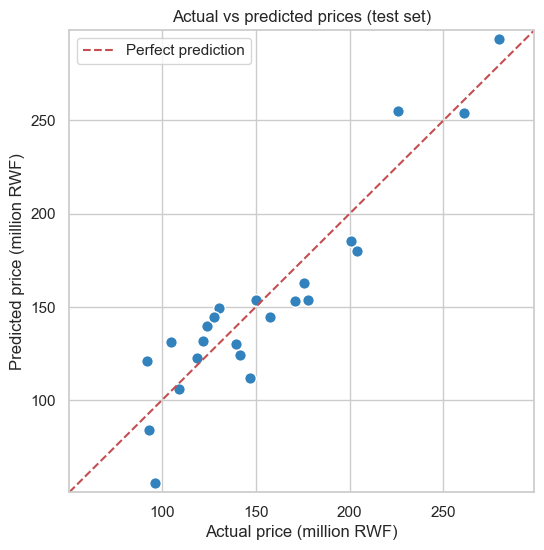

In [26]:
y_pred_test = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, color="#3182bd", edgecolor="white", s=70)
lims = [min(y_test.min(), y_pred_test.min()) - 5,
        max(y_test.max(), y_pred_test.max()) + 5]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual price (million RWF)")
ax.set_ylabel("Predicted price (million RWF)")
ax.set_title("Actual vs predicted prices (test set)")
ax.legend(); plt.show()

C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


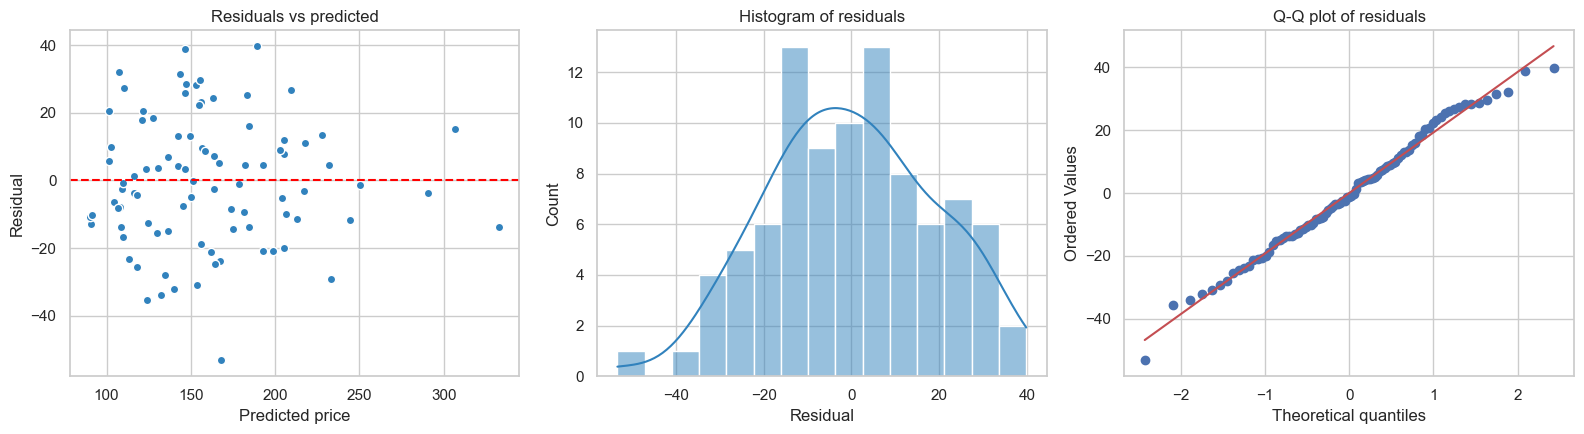

In [27]:
pred_train = model.predict(X_train)
res_train = y_train - pred_train

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_train, res_train, color="#3182bd", edgecolor="white")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted price"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs predicted")

sns.histplot(res_train, bins=15, kde=True, ax=axes[1], color="#3182bd")
axes[1].set_xlabel("Residual"); axes[1].set_title("Histogram of residuals")

stats.probplot(res_train, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")

plt.tight_layout(); plt.show()

In [28]:
Z = model.named_steps["prep"].transform(X_train)
Z = np.column_stack([np.ones(len(Z)), Z])      # add intercept column

print("Shapiro-Wilk p (normal residuals):", round(shapiro(res_train)[1], 3))
print("Durbin-Watson (independence):     ", round(durbin_watson(res_train), 2))
print("Breusch-Pagan p (constant variance):", round(het_breuschpagan(res_train, Z)[1], 3))

Shapiro-Wilk p (normal residuals): 0.692
Durbin-Watson (independence):      2.09
Breusch-Pagan p (constant variance): 0.741


In [29]:
ols = sm.OLS(y_train.values, Z).fit()
cooks = ols.get_influence().cooks_distance[0]

top = pd.DataFrame({
    "House_ID": df.loc[X_train.index, "House_ID"].values,
    "Age": X_train["House_Age_Years"].values,
    "Cooks_D": cooks.round(3)
}).sort_values("Cooks_D", ascending=False).head(3)
display(top)

# Refit without house 1034, same split, same test set
keep = df.loc[X_train.index, "House_ID"].values != 1034
m2 = Pipeline([("prep", preprocess), ("reg", LinearRegression())]).fit(X_train[keep], y_train[keep])
p2 = m2.predict(X_test)
print("Without 1034 -> test R²:", round(r2_score(y_test, p2), 3),
      "| RMSE:", round(np.sqrt(mean_squared_error(y_test, p2)), 2),
      "| age coef:", round(m2.named_steps["reg"].coef_[3], 3))

,House_ID,Age,Cooks_D
0,1034,75.0,0.126
88,1099,15.6,0.060
3,1115,2.6,0.057


Without 1034 -> test R²: 0.857 | RMSE: 19.06 | age coef: -0.778


In [30]:
import joblib

joblib.dump(model, "house_price_model.sav")
print("Saved: house_price_model.sav")

Saved: house_price_model.sav


In [31]:
pred_original = model.predict(X_test)

loaded_model = joblib.load("house_price_model.sav")
pred_loaded = loaded_model.predict(X_test)

print("Exactly identical:", np.array_equal(pred_original, pred_loaded))
print("Largest difference:", np.abs(pred_original - pred_loaded).max())

Exactly identical: True
Largest difference: 0.0


In [32]:
new_house = pd.DataFrame({
    "Area_m2": [120.0],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "House_Age_Years": [5.0],
    "Distance_to_City_km": [4.0],
    "Parking_Spaces": [1],
    "Neighborhood": ["Kicukiro"]
})

price = loaded_model.predict(new_house)[0]
print(f"Predicted price: {price:.1f} million RWF")

Predicted price: 133.2 million RWF


In [33]:
import sklearn, pandas, numpy, joblib
print("scikit-learn==" + sklearn.__version__)
print("pandas==" + pandas.__version__)
print("numpy==" + numpy.__version__)
print("joblib==" + joblib.__version__)

scikit-learn==1.2.2
pandas==2.1.4
numpy==1.26.4
joblib==1.2.0
